# Class 04 — P-values and Confidence Intervals
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

---

P-values are among the most misunderstood objects in statistics. This notebook builds them from first principles — via maximum likelihood and tail probabilities — then systematically works through the key misinterpretations from Greenland et al. (2016).

**Contents:**
1. [Setup](#1)
2. [MLE vs. P-value — From the Slide Example](#2)
3. [Misinterpretation #1 — P-value ≠ P(H₀ is true)](#3)
4. [Misinterpretation #4 — p > 0.05 ≠ H₀ is true](#4)
5. [Misinterpretation #7 — Significance ≠ Importance](#5)
6. [Confidence Intervals and Duality with P-values](#6)
7. [Misinterpretation #19 — What a 95% CI Actually Means](#7)
8. [Misinterpretation #21 — Overlapping CIs Trap](#8)

---

<a id='1'></a>
## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
BLUE='#2563EB'; RED='#DC2626'; GREEN='#16A34A'; ORANGE='#D97706'; GRAY='#6B7280'
print('Ready.')

Ready.


<a id='2'></a>
## 2. MLE vs. P-value — From the Slide Example

For $Z \sim N(\theta, 1)$ with $z = 1.5$, the slides contrast two approaches:
- **MLE:** uses the density $\phi(z - \theta)$ — picks the model that makes the data most probable
- **Testing:** uses the tail probability $P(Z \geq z \mid \theta)$ — rejects models that make the data look too extreme

The **p-value** is the tail probability specifically under $H_0: \theta = 0$.

In [4]:
from scipy.stats import norm

z_obs = 1.5
thetas = [-1, 0, 1]
print("=== Maximum Likelihood vs. P-value (slides example) ===")
print(f"Observed value: z = {z_obs}")
print()
print("Maximum Likelihood (density at observed value):")
for theta in thetas:
    lik = norm.pdf(z_obs, loc=theta, scale=1)
    print(f"  theta={theta:+.0f}: phi(z-theta) = {lik:.3f}", "<-- MLE" if theta==1 else "")

print()
print("One-sided tail probability P(Z >= z | theta):")
for theta in thetas:
    tail = norm.sf(z_obs, loc=theta, scale=1)
    print(f"  theta={theta:+.0f}: P(Z >= {z_obs}) = {tail:.3f}", "<-- rejected (too extreme)" if theta==-1 else "")

print()
pval = 2 * norm.sf(z_obs, loc=0, scale=1)
print(f"P-value (composite H0: theta=0, two-sided):")
print(f"  p = 2*(1-Phi({z_obs})) = {pval:.3f}")
print()
print("KEY: MLE picks the BEST model. Testing REJECTS the WORST ones. Different logic.")

=== Maximum Likelihood vs. P-value (slides example) ===
Observed value: z = 1.5

Maximum Likelihood (density at observed value):
  theta=-1: phi(z-theta) = 0.018 
  theta=+0: phi(z-theta) = 0.130 
  theta=+1: phi(z-theta) = 0.352 <-- MLE

One-sided tail probability P(Z >= z | theta):
  theta=-1: P(Z >= 1.5) = 0.006 <-- rejected (too extreme)
  theta=+0: P(Z >= 1.5) = 0.067 
  theta=+1: P(Z >= 1.5) = 0.309 

P-value (composite H0: theta=0, two-sided):
  p = 2*(1-Phi(1.5)) = 0.134

KEY: MLE picks the BEST model. Testing REJECTS the WORST ones. Different logic.


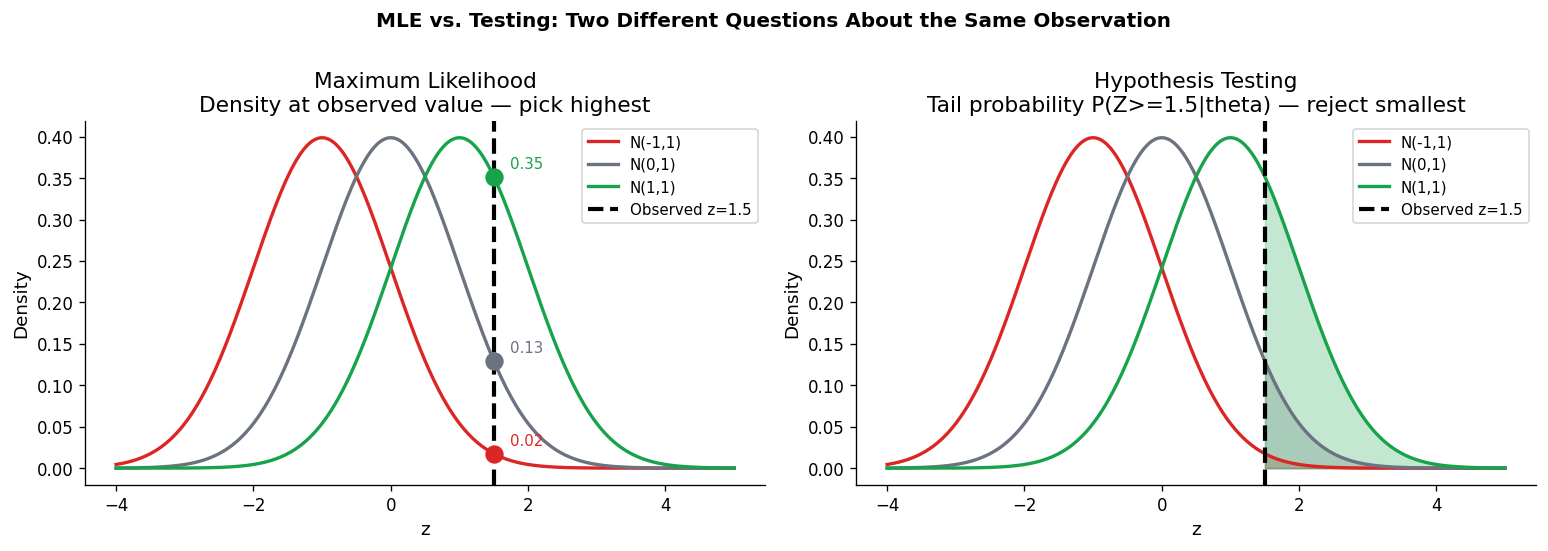

Saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

z_range = np.linspace(-4, 5, 400)

# Left: densities at z_obs (MLE logic)
ax = axes[0]
for theta, col, label in [(-1, RED, 'theta=-1'), (0, GRAY, 'theta=0 (H0)'), (1, GREEN, 'theta=1')]:
    ax.plot(z_range, norm.pdf(z_range, theta, 1), color=col, lw=2, label=f'N({theta},1)')
ax.axvline(z_obs, color='black', lw=2.5, ls='--', label=f'Observed z={z_obs}')
for theta, col in [(-1,RED),(0,GRAY),(1,GREEN)]:
    lik = norm.pdf(z_obs, theta, 1)
    ax.plot(z_obs, lik, 'o', color=col, ms=10)
    ax.annotate(f'{lik:.2f}', (z_obs, lik), textcoords='offset points',
                xytext=(10,5), fontsize=9, color=col)
ax.set_title('Maximum Likelihood\nDensity at observed value — pick highest')
ax.set_xlabel('z'); ax.set_ylabel('Density')
ax.legend(fontsize=9)

# Right: tail probabilities (testing logic)
ax2 = axes[1]
for theta, col in [(-1,RED),(0,GRAY),(1,GREEN)]:
    ax2.plot(z_range, norm.pdf(z_range, theta, 1), color=col, lw=2, label=f'N({theta},1)')
    # Shade tail
    tail_x = z_range[z_range >= z_obs]
    ax2.fill_between(tail_x, norm.pdf(tail_x, theta, 1), alpha=0.25, color=col)
ax2.axvline(z_obs, color='black', lw=2.5, ls='--', label=f'Observed z={z_obs}')
ax2.set_title(f'Hypothesis Testing\nTail probability P(Z>={z_obs}|theta) — reject smallest')
ax2.set_xlabel('z'); ax2.set_ylabel('Density')
ax2.legend(fontsize=9)

plt.suptitle('MLE vs. Testing: Two Different Questions About the Same Observation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_mle_vs_pvalue.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='3'></a>
## 3. Misinterpretation #1 — P-value ≠ P(H₀ is true)

The p-value is $P(\text{data} \mid H_0)$. The Bayesian posterior $P(H_0 \mid \text{data})$ requires a prior. Confusing these two is the root of much of the replication crisis, and it connects directly to Ioannidis' PPV framework from Class 09.

In [6]:
# Misinterpretation #1: "P-value = P(H0 is true)"
# The correct Bayesian version requires a prior pi0 = P(H0)
# P(H0 | |Z|>=z) = pi0 * pvalue / P(|Z|>=z)
# This is the FDR -- identical to Ioannidis (Class 09)

z_obs = 1.5
pval  = 2 * norm.sf(abs(z_obs))
pi0_values = [0.1, 0.5, 0.9, 0.99]

print("Misinterpretation #1: p-value is NOT P(H0 is true)")
print(f"p-value = {pval:.3f}")
print()
print("The correct Bayesian posterior P(H0 | significant) depends on the prior:")
print(f"{'Prior pi0':>12} {'P(H0|sig)=FDR':>16} {'Interpretation':>30}")
print('-'*62)
for pi0 in pi0_values:
    p_sig  = pi0*pval + (1-pi0)*0.8   # P(|Z|>=z) = mix of pval and power
    fdr    = pi0 * pval / p_sig
    print(f"  pi0={pi0:>4}  FDR={fdr:>6.3f}  {'Most findings false!' if fdr>0.5 else 'Reasonable'}")
print()
print("The p-value alone cannot tell you P(H0 is true) without a prior.")

Misinterpretation #1: p-value is NOT P(H0 is true)
p-value = 0.134

The correct Bayesian posterior P(H0 | significant) depends on the prior:
   Prior pi0    P(H0|sig)=FDR                 Interpretation
--------------------------------------------------------------
  pi0= 0.1  FDR= 0.018  Reasonable
  pi0= 0.5  FDR= 0.143  Reasonable
  pi0= 0.9  FDR= 0.601  Most findings false!
  pi0=0.99  FDR= 0.943  Most findings false!

The p-value alone cannot tell you P(H0 is true) without a prior.


<a id='4'></a>
## 4. Misinterpretation #4 — p > 0.05 ≠ H₀ is true

In a composite test, failing to reject $H_0$ means the data are consistent with $H_0$ — but also consistent with many nearby alternatives. Non-significance is not evidence of absence.

In [7]:
# Misinterpretation #4: "p > 0.05 means H0 is true"
z_obs = 1.5
print(f"Observed z = {z_obs}")
print()
print("In a composite test H0:theta=0 vs HA:theta!=0,")
print("MANY nearby thetas are consistent with the data:")
for theta in [-0.5, -0.1, 0.0, 0.1, 0.5, 1.0]:
    pval_theta = 2*(1 - norm.cdf(abs(z_obs - theta)))
    consistent = pval_theta > 0.05
    print(f"  theta={theta:+.1f}: p={pval_theta:.3f}  {'compatible with data' if consistent else 'rejected'}")
print()
print("Failing to reject theta=0 does NOT mean theta=0.")
print("It means the data are consistent with theta=0 AND many nearby values.")

Observed z = 1.5

In a composite test H0:theta=0 vs HA:theta!=0,
MANY nearby thetas are consistent with the data:
  theta=-0.5: p=0.046  rejected
  theta=-0.1: p=0.110  compatible with data
  theta=+0.0: p=0.134  compatible with data
  theta=+0.1: p=0.162  compatible with data
  theta=+0.5: p=0.317  compatible with data
  theta=+1.0: p=0.617  compatible with data

Failing to reject theta=0 does NOT mean theta=0.
It means the data are consistent with theta=0 AND many nearby values.


<a id='5'></a>
## 5. Misinterpretation #7 — Statistical Significance ≠ Practical Importance

For a test of proportions, the Z-statistic grows as $\sqrt{n}$. With enough data, any nonzero effect becomes significant — no matter how tiny. Significance is mostly a function of sample size; importance must be judged by effect size.

In [8]:
# Misinterpretation #7: "Statistical significance = practical importance"
# Effect of sample size on significance, independent of effect size
true_effect = 0.01   # tiny real-world effect (1% difference in proportions)
p1, p2 = 0.50, 0.51
sample_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]

print("Misinterpretation #7: Statistical significance inflates with sample size")
print(f"True effect: p1-p2 = {p2-p1} (clinically trivial)")
print()
print(f"{'n':>10} {'Z statistic':>14} {'p-value':>12} {'Significant?':>14}")
print('-'*54)
for n in sample_sizes:
    sigma = np.sqrt(p1*(1-p1)/n + p2*(1-p2)/n)
    Z     = (p2 - p1) / sigma
    pval  = 2 * norm.sf(abs(Z))
    sig   = "YES ***" if pval < 0.05 else "no"
    print(f"  {n:>8,}  Z={Z:>8.2f}      p={pval:>8.4f}  {sig}")
print()
print("The effect size is constant. Only n changes.")
print("Statistical significance is mostly a function of sample size.")

Misinterpretation #7: Statistical significance inflates with sample size
True effect: p1-p2 = 0.010000000000000009 (clinically trivial)

         n    Z statistic      p-value   Significant?
------------------------------------------------------
       100  Z=    0.14      p=  0.8875  no
       500  Z=    0.32      p=  0.7518  no
     1,000  Z=    0.45      p=  0.6547  no
     5,000  Z=    1.00      p=  0.3173  no
    10,000  Z=    1.41      p=  0.1573  no
    50,000  Z=    3.16      p=  0.0016  YES ***
   100,000  Z=    4.47      p=  0.0000  YES ***

The effect size is constant. Only n changes.
Statistical significance is mostly a function of sample size.


<a id='6'></a>
## 6. Confidence Intervals and Duality with P-values

For $Z \sim N(\theta,1)$ with MLE $\hat\theta = z$, the $1-\alpha$ CI is $[z - z_\alpha, z + z_\alpha]$.

**Duality:** $\theta_0$ is excluded from the CI if and only if the p-value for $H_0: \theta = \theta_0$ is less than $\alpha$.

In [9]:
# CI duality with p-values
z_obs = 1.5
alpha = 0.05
z_alpha = norm.ppf(1 - alpha/2)  # 1.96 for two-sided

CI_lo = z_obs - z_alpha
CI_hi = z_obs + z_alpha

print(f"Observed: z = {z_obs}, MLE: theta_hat = {z_obs}")
print(f"95% CI = [{CI_lo:.3f}, {CI_hi:.3f}]")
print()

# Duality: CI excludes theta0 iff p-value < alpha
theta_values = [CI_lo - 0.5, CI_lo, 0.0, CI_hi, CI_hi + 0.5]
print("Duality between CI and p-value:")
print(f"{'theta0':>8} {'p-value':>10} {'Significant?':>14} {'In CI?':>8}")
print('-'*44)
for theta0 in theta_values:
    pval_t  = 2*(1 - norm.cdf(abs(z_obs - theta0)))
    sig     = pval_t < alpha
    in_ci   = CI_lo <= theta0 <= CI_hi
    print(f"  {theta0:>6.2f}   p={pval_t:.3f}   {'YES' if sig else 'no ':>6}        {'NO' if sig else 'YES':>6}")
print()
print("theta0 excluded by CI  iff  p-value < 0.05  (exact duality)")

Observed: z = 1.5, MLE: theta_hat = 1.5
95% CI = [-0.460, 3.460]

Duality between CI and p-value:
  theta0    p-value   Significant?   In CI?
--------------------------------------------
   -0.96   p=0.014      YES            NO
   -0.46   p=0.050      no            YES
    0.00   p=0.134      no            YES
    3.46   p=0.050      no            YES
    3.96   p=0.014      YES            NO

theta0 excluded by CI  iff  p-value < 0.05  (exact duality)


<a id='7'></a>
## 7. Misinterpretation #19 — What a 95% CI Actually Means

The 95% is a property of the **procedure**, not of any particular interval. Once computed, a specific interval either contains $\theta$ or it doesn't. We demonstrate via simulation.

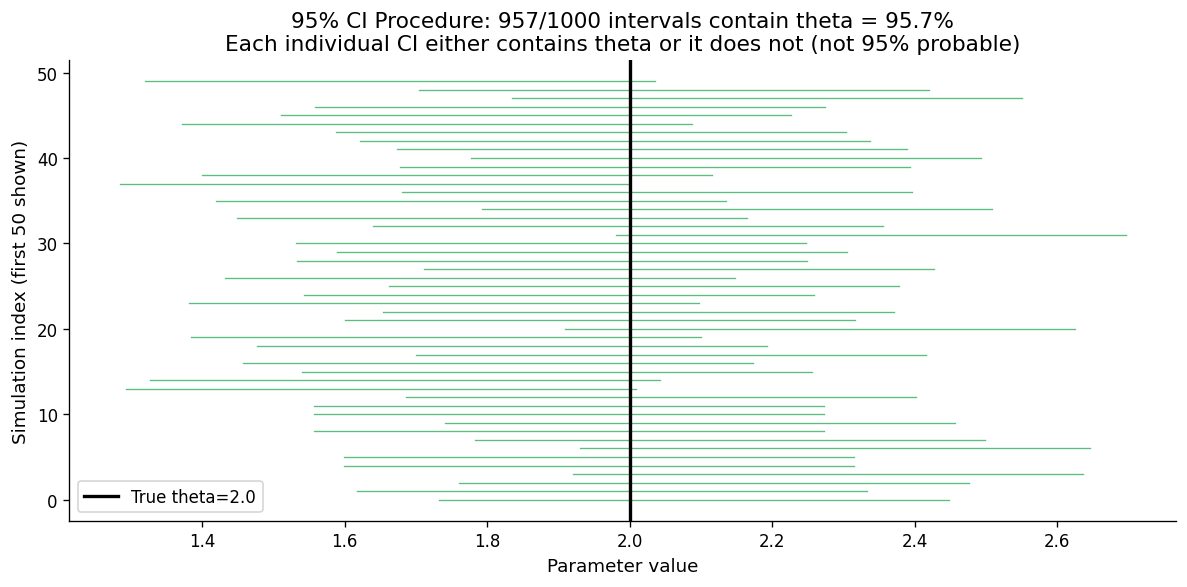

Saved.


In [10]:
# Misinterpretation #19: "95% CI has 95% chance of containing theta"
# Correct: 95% of RANDOM intervals from the procedure contain theta
n_sims = 1000
true_theta = 2.0
n_obs = 30

covered = 0
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(n_sims):
    z = np.random.normal(true_theta, 1/np.sqrt(n_obs))
    lo = z - 1.96/np.sqrt(n_obs)
    hi = z + 1.96/np.sqrt(n_obs)
    c  = lo <= true_theta <= hi
    if i < 50:
        col = GREEN if c else RED
        ax.plot([lo, hi], [i, i], color=col, lw=0.8, alpha=0.7)
    if c: covered += 1

ax.axvline(true_theta, color='black', lw=2, label=f'True theta={true_theta}')
ax.set_xlabel('Parameter value')
ax.set_ylabel('Simulation index (first 50 shown)')
ax.set_title(f'95% CI Procedure: {covered}/{n_sims} intervals contain theta = {covered/n_sims:.1%}\n'
             f'Each individual CI either contains theta or it does not (not 95% probable)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/03_ci_coverage.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='8'></a>
## 8. Misinterpretation #21 — The Overlapping CIs Trap

Two individual CIs can overlap substantially while the CI for their *difference* excludes zero. This is because the CI for a difference is $1/\sqrt{2} \approx 0.7$ times the sum of the two individual CI widths for independent estimates.

In [11]:
# Misinterpretation #21: overlapping CIs do not mean non-significant difference
np.random.seed(1)
n_per = 100
# Two groups with means mu1=0, mu2=0.4 (true difference = 0.4)
mu1, mu2 = 0.0, 0.4
y1 = np.random.normal(mu1, 1, n_per)
y2 = np.random.normal(mu2, 1, n_per)

se = 1/np.sqrt(n_per)
ci1 = (y1.mean() - 1.96*se, y1.mean() + 1.96*se)
ci2 = (y2.mean() - 1.96*se, y2.mean() + 1.96*se)

# CI for the difference
diff_est = y2.mean() - y1.mean()
se_diff  = np.sqrt(2)*se
ci_diff  = (diff_est - 1.96*se_diff, diff_est + 1.96*se_diff)
pval_diff = 2*(1 - norm.cdf(abs(diff_est/se_diff)))

print(f"Group 1: mean={y1.mean():.3f}, 95% CI=[{ci1[0]:.3f}, {ci1[1]:.3f}]")
print(f"Group 2: mean={y2.mean():.3f}, 95% CI=[{ci2[0]:.3f}, {ci2[1]:.3f}]")
print(f"CIs overlap: {ci1[1] > ci2[0] and ci2[1] > ci1[0]}")
print()
print(f"Difference: {diff_est:.3f}, 95% CI=[{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]")
print(f"P-value for difference: {pval_diff:.4f}  {'< 0.05 SIGNIFICANT' if pval_diff<0.05 else '>= 0.05'}")
print()
print(f"The two individual CIs overlap, yet the difference IS significant.")
print(f"Width ratio: CI_diff / sum(CI widths) = {2*1.96*se_diff:.3f} / {2*(2*1.96*se):.3f} = {se_diff/se/2:.3f}  (= 1/sqrt(2) for independent CIs)")

Group 1: mean=0.061, 95% CI=[-0.135, 0.257]
Group 2: mean=0.553, 95% CI=[0.357, 0.749]
CIs overlap: False

Difference: 0.492, 95% CI=[0.215, 0.769]
P-value for difference: 0.0005  < 0.05 SIGNIFICANT

The two individual CIs overlap, yet the difference IS significant.
Width ratio: CI_diff / sum(CI widths) = 0.554 / 0.784 = 0.707  (= 1/sqrt(2) for independent CIs)


---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **P-value definition** | Tail probability under H₀: P(|Z| ≥ z_obs \| H₀) |
| **MLE vs. testing** | MLE picks the best model (density); testing rejects the worst (tail) |
| **Misinterpretation #1** | p-value ≠ P(H₀ is true); that requires a Bayesian prior |
| **Misinterpretation #4** | p > 0.05 means data are consistent with H₀ — not that H₀ is true |
| **Misinterpretation #7** | Significance grows with n regardless of effect size |
| **CI duality** | theta₀ outside CI ↔ p-value < α (exact equivalence) |
| **Misinterpretation #19** | 95% coverage is a property of the procedure, not of one specific interval |
| **Misinterpretation #21** | Overlapping CIs do not imply non-significant difference |
| **CIs vs. p-values** | CIs show estimate + uncertainty; p-values force binary think |

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*